# 02 · OE2 (ICP) y OE3 (IPD)
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.4 (ICP), §3.5 (IPD) y el análisis de sensibilidad del piso de la función V definido en §3.4.* **Requiere `00_preparacion_datos`.**

In [1]:
# Bloque de librerías común a los cuadernos 00-04 (algunos módulos se usan solo en 02-04)
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Carga de insumos

Insumos del cuaderno 00 (`data/intermedia/`): la matriz ruta-estación estandarizada (con capacidad por ruta y orden de parada), el catálogo de servicios troncales y las validaciones consolidadas.

In [2]:
import os
import pandas as pd

RAIZ = os.getcwd()
if os.path.basename(RAIZ) == 'notebooks':
    RAIZ = os.path.dirname(RAIZ)
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

matriz       = pd.read_parquet(os.path.join(DATA_INT, 'matriz_estandarizada.parquet'))
troncal_serv = pd.read_parquet(os.path.join(DATA_INT, 'troncal_serv.parquet'))
validaciones = pd.read_parquet(os.path.join(DATA_INT, 'validaciones_consolidadas.parquet'))
print('Insumos cargados: matriz, troncal_serv, validaciones')

Insumos cargados: matriz, troncal_serv, validaciones


## 1. Construcción del Índice de Cobertura Ponderada (ICP) — §3.4

El ICP cuantifica la **cobertura de servicio asignada** a cada estación. A diferencia de un conteo simple de rutas, integra tres factores, cada uno con su justificación:

- **Número de rutas** que sirven la estación: su conectividad dentro de la red.
- **Tipo de bus por ruta → capacidad nominal del TCQSM** (TRB, 2013): biarticulado **250**, articulado **160**, padrón dual **80** pasajeros. Se usa el TCQSM y no el catálogo oficial de estaciones porque este marca sus campos de capacidad "en proceso de actualización" (§3.1d).
- **Posición en la ruta (ponderación en V).** Un bus sale vacío del extremo de su recorrido, se llena hacia el centro y se vacía hacia el otro extremo (perfil de carga documentado en BRT: Hidalgo y Graftieaux, 2008; TRB, 2013). La cobertura que una ruta ofrece a cada estación no es uniforme: el factor V vale 1,0 en los extremos y decrece hasta un **piso de 0,30** en el centro, porque incluso en el punto de máxima carga el bus conserva capacidad residual. La sensibilidad de los resultados a ese piso se evalúa en la sección 4 de este cuaderno.

**Supuestos a tener presentes (§3.4):**
- La V es **simétrica** porque no hay datos públicos de carga por sentido que permitan calibrar una función asimétrica; es la aproximación más parsimoniosa, pero puede sobreestimar la cobertura en estaciones intermedias de corredores con demanda direccional marcada.
- El ICP es **estático** (no varía por hora ni por tipo de día): TransMilenio no publica frecuencias ni programación de despachos del troncal para 2024–2025 (el GTFS disponible cubre solo el zonal). Es una limitación explícita del estudio y la razón de restringir el análisis del IPD a días hábiles (sección 2).

In [3]:
# =============================================
# CAPACIDAD POR TIPO DE BUS — VIENE EN LA MATRIZ
# =============================================

assert matriz['capacidad'].isin([250, 160, 80]).all(), 'Capacidad fuera de {250, 160, 80}'
assert matriz.groupby('ruta')['capacidad'].nunique().eq(1).all(), 'Hay rutas con capacidad mixta'

print("Distribución de capacidades (columna de la matriz):")
print(matriz.groupby('capacidad')['ruta'].nunique().to_frame('n_rutas'))
print("\nRutas por tipo y capacidad:")
print(matriz.drop_duplicates('ruta').groupby(['tipo', 'capacidad'])['ruta'].count().to_frame('n_rutas'))

Distribución de capacidades (columna de la matriz):
           n_rutas
capacidad         
80              10
160             31
250             61

Rutas por tipo y capacidad:
                   n_rutas
tipo    capacidad         
Dual    80              10
        160              2
Expreso 160             23
        250             59
Fácil   160              6
        250              2


In [4]:
# =============================================
# CÁLCULO DEL ICP CON PONDERACIÓN EN V
# =============================================

# Largo de cada ruta
route_len = matriz.groupby('ruta')['orden'].max().reset_index()
route_len.columns = ['ruta', 'len_ruta']
matriz = matriz.merge(route_len, on='ruta')

# Factor V (§3.4): factorV = max(1 - 2*min(pos-1, len-pos)/len, 0.30)
# 'orden' es 1-indexado (1 = primera parada), de modo que dist_extremo vale 0 en los
# extremos (factor 1.0) y es máxima en el centro de la ruta (factor = piso 0.30).
# El piso 0.30 refleja la capacidad residual del bus en su punto de máxima carga;
# su efecto se somete a prueba en el análisis de sensibilidad (sección 4).
matriz['dist_extremo'] = matriz.apply(
    lambda r: min(r['orden'] - 1, r['len_ruta'] - r['orden']), axis=1
)
matriz['factor_v'] = (1 - 2 * matriz['dist_extremo'] / matriz['len_ruta']).clip(lower=0.30)

# Capacidad ponderada
matriz['cap_ponderada'] = matriz['capacidad'] * matriz['factor_v']

# ICP por estación
icp = matriz.groupby('estacion').agg(
    icp=('cap_ponderada', 'sum'),
    n_rutas=('ruta', 'nunique'),
    cap_plana=('capacidad', 'sum')
).reset_index()

# Resumen
print(f"ICP calculado para {len(icp)} estaciones")
print(f"\nTop 10 estaciones por ICP (mayor cobertura asignada):")
print(icp.nlargest(10, 'icp')[['estacion', 'icp', 'n_rutas', 'cap_plana']].to_string(index=False))
print(f"\nBottom 10 estaciones por ICP (menor cobertura asignada):")
print(icp.nsmallest(10, 'icp')[['estacion', 'icp', 'n_rutas', 'cap_plana']].to_string(index=False))

ICP calculado para 148 estaciones

Top 10 estaciones por ICP (mayor cobertura asignada):
                             estacion         icp  n_rutas  cap_plana
                  Toberín - Foundever 3985.577985       22       4690
                         Portal Norte 3670.606061       18       3690
                      Portal Américas 3300.000000       15       3300
                          Portal Suba 3300.000000       15       3300
       Portal Sur - JFK Coop. financ. 3140.000000       14       3140
                            Portal 80 2980.000000       13       2980
                           La Campiña 2891.938062       15       3300
                          Portal Usme 2870.000000       14       2870
Portal Eldorado - C.C. NUESTRO BOGOTÁ 2730.000000       13       2730
                            San Mateo 2660.000000       11       2660

Bottom 10 estaciones por ICP (menor cobertura asignada):
               estacion        icp  n_rutas  cap_plana
              Policarpa 171.

Estaciones con ICP y capacidad oficial: 145

=== VALIDEZ CONVERGENTE: ICP vs. capacidad oficial (Spearman) ===
  ICP vs capacidad articulada     (n=145): rho=0.461, p=5.36e-09
  ICP vs capacidad biarticulada   (n=143): rho=0.436, p=5.21e-08
  ICP vs numero de vagones        (n=144): rho=0.250, p=2.48e-03


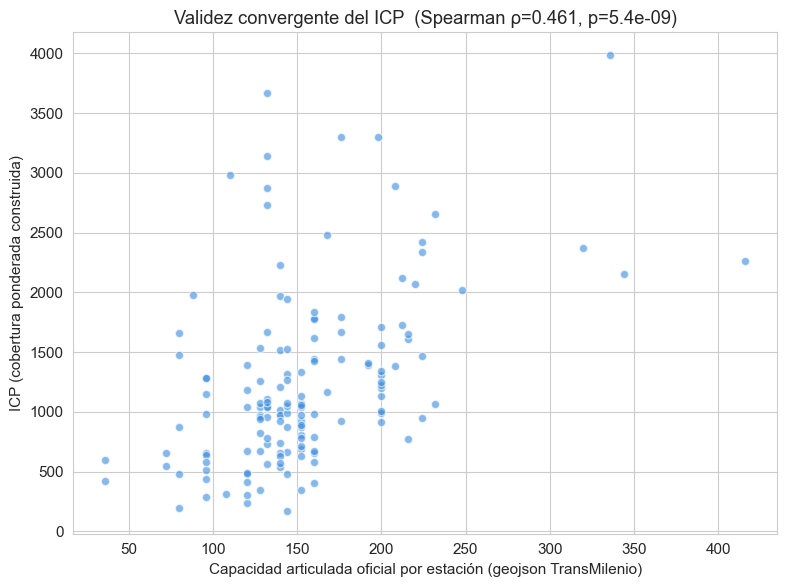

In [5]:
# =============================================
# VALIDACIÓN EXTERNA DEL ICP (validez convergente)
# =============================================
# El ICP es un proxy construido de la cobertura asignada. Para validarlo contra una
# medida externa (atendiendo la retroalimentación), se contrasta con la capacidad
# fisica oficial por estacion del geojson de TransMilenio (cap_art, cap_biart, num_vag).
# Si correlaciona positiva y significativamente, el ICP capta diferencias reales de
# cobertura (validez CONVERGENTE; no se espera identidad: miden servicio asignado vs.
# infraestructura fisica, y el geojson marca las capacidades "en proceso de actualizacion").
import json
from scipy.stats import spearmanr

DATA_SOP = os.path.join(RAIZ, 'data', 'soporte')
def z5(c): return str(c).strip().zfill(5)

gj = json.load(open(os.path.join(DATA_SOP, 'catalogo_estaciones_troncales.geojson'), encoding='utf-8'))
cap_geo = pd.DataFrame([{'code': z5(f['properties']['num_est']),
                         'cap_art':   f['properties'].get('cap_art'),
                         'cap_biart': f['properties'].get('cap_biart'),
                         'num_vag':   f['properties'].get('num_vag')} for f in gj['features']])

code_to_name = json.load(open(os.path.join(DATA_SOP, 'code_to_matriz.json'), encoding='utf-8'))
cap_geo['estacion'] = cap_geo['code'].map({z5(k): v for k, v in code_to_name.items()})
cap_est = (cap_geo.dropna(subset=['estacion'])
           .groupby('estacion')[['cap_art', 'cap_biart', 'num_vag']].sum(min_count=1).reset_index())

val = icp.merge(cap_est, on='estacion', how='inner')
val = val[val['cap_art'].notna() & (val['cap_art'] > 0)]
print(f"Estaciones con ICP y capacidad oficial: {len(val)}\n")

print("=== VALIDEZ CONVERGENTE: ICP vs. capacidad oficial (Spearman) ===")
for col, etq in [('cap_art', 'capacidad articulada'), ('cap_biart', 'capacidad biarticulada'),
                 ('num_vag', 'numero de vagones')]:
    sub = val[val[col].notna() & (val[col] > 0)]
    rho, p = spearmanr(sub['icp'], sub[col])
    print(f"  ICP vs {etq:24s} (n={len(sub):3d}): rho={rho:.3f}, p={p:.2e}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(val['cap_art'], val['icp'], alpha=0.6, color='#378ADD', edgecolor='white')
rho_main, p_main = spearmanr(val['icp'], val['cap_art'])
ax.set_xlabel('Capacidad articulada oficial por estación (geojson TransMilenio)')
ax.set_ylabel('ICP (cobertura ponderada construida)')
ax.set_title(f'Validez convergente del ICP  (Spearman ρ={rho_main:.3f}, p={p_main:.1e})')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe2_validacion_externa_icp.png'), dpi=150, bbox_inches='tight'); plt.show()

## 2. Cálculo del Índice de Presión de Demanda (IPD) — §3.5

$$IPD_{e,t} = \frac{V_{e,t}}{ICP_e}$$

Adaptación del ratio clásico volumen/capacidad (V/C; TRB, 2010) a los datos abiertos disponibles. Un IPD alto indica que la estación recibe más demanda de la que su cobertura asignada sugiere que puede absorber, y permite comparar estaciones entre sí independientemente de su tamaño absoluto.

**Sesgo heredado del ICP estático (§3.4), clave para interpretar todo lo que sigue:** como el denominador no recoge que en hora pico se despacha con mayor frecuencia, el IPD tiende a **sobreestimar** la presión en pico y a **subestimarla** en valle; lo mismo entre tipos de día (los domingos y festivos el servicio es reducido y un ICP constante sobreestima la oferta efectiva). Por eso:
- el análisis de desbalance se restringe a **días hábiles no festivos**, donde el ICP estático representa mejor la oferta operada (el desbalance en domingos/festivos queda como limitación y trabajo futuro);
- la comparación válida es **entre estaciones dentro de una misma franja** (todas comparten el mismo denominador), no entre franjas distintas de una misma estación;
- el IPD se lee como **presión relativa a la cobertura asignada**, no como saturación física: un mismo IPD implica cargas absolutas distintas en estaciones con distinto ICP.

In [6]:
# =============================================
# MERGE VALIDACIONES CON ICP -> CÁLCULO DEL IPD
# =============================================

ipd_df = validaciones.merge(icp[['estacion', 'icp', 'n_rutas']], on='estacion', how='left')

n_sin_icp = ipd_df['icp'].isna().sum()
print(f"Registros sin ICP (estación no en matriz): {n_sin_icp} ({n_sin_icp/len(ipd_df)*100:.1f}%)")
ipd_df = ipd_df[ipd_df['icp'].notna() & (ipd_df['icp'] > 0)].copy()

ipd_df['ipd'] = ipd_df['validaciones'] / ipd_df['icp']

print(f"\n{'='*50}")
print(f"IPD calculado: {len(ipd_df):,} registros")
print(f"Estaciones:    {ipd_df['estacion'].nunique()}")
print(f"\nEstadísticas del IPD:")
print(ipd_df['ipd'].describe().round(3))

Registros sin ICP (estación no en matriz): 0 (0.0%)

IPD calculado: 8,192,438 registros
Estaciones:    148

Estadísticas del IPD:
count    8192438.000
mean           0.104
std            0.143
min            0.000
25%            0.019
50%            0.058
75%            0.127
max            2.689
Name: ipd, dtype: float64


## 3. Análisis exploratorio del IPD

Sobre días hábiles no festivos (§3.6). El "pico AM" se define como la franja 6:00–8:59, la de mayor demanda matutina identificada en el perfil horario del cuaderno 01.

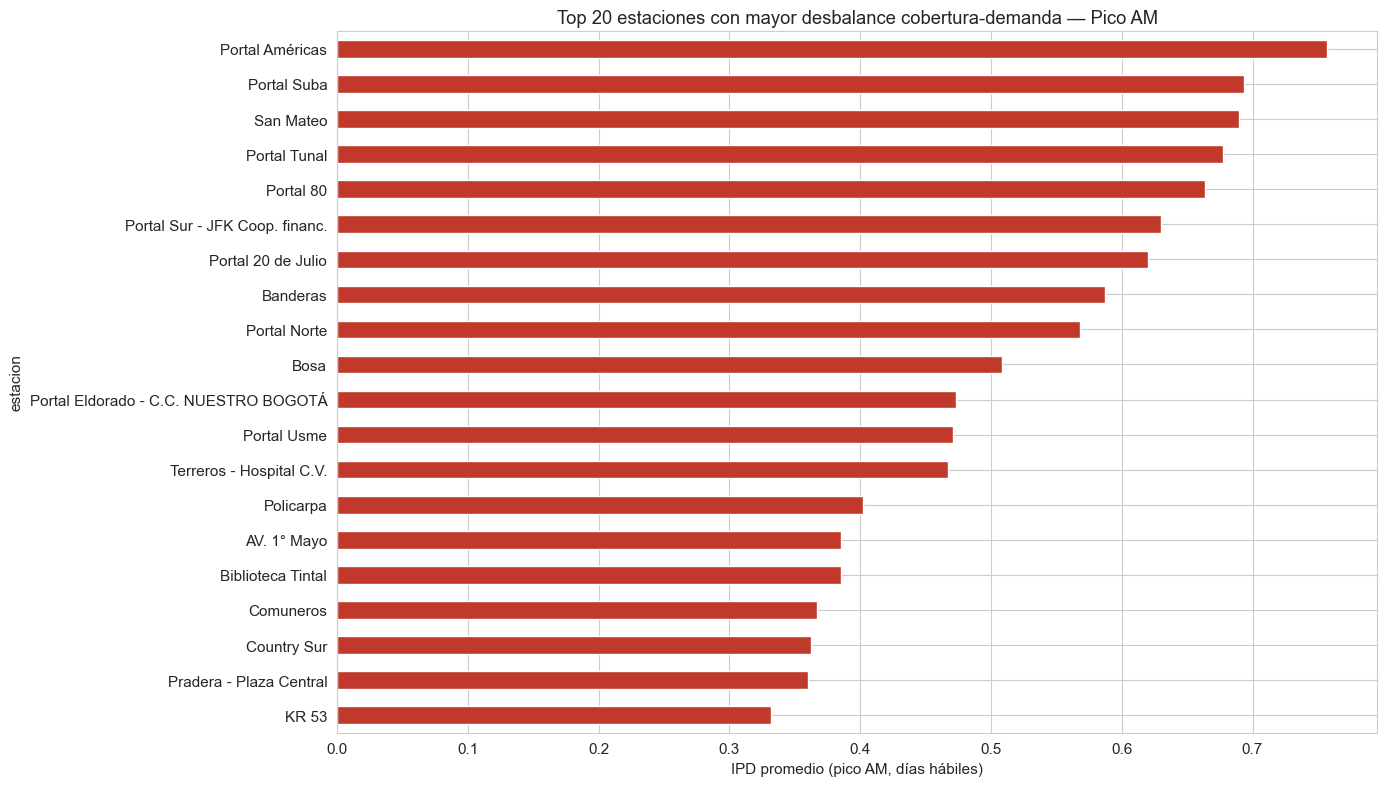

In [7]:
# =============================================
# TOP 20 ESTACIONES CON MAYOR DESBALANCE (PICO AM, DÍAS HÁBILES)
# =============================================

habiles_pico = ipd_df[
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0) &
    (ipd_df['hora'].between(6, 8))
]

ipd_pico = habiles_pico.groupby('estacion')['ipd'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
ipd_pico.head(20).plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('IPD promedio (pico AM, días hábiles)')
ax.set_title('Top 20 estaciones con mayor desbalance cobertura-demanda — Pico AM')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig1_ipd_top20_pico_am.png'), dpi=150, bbox_inches='tight')
plt.show()

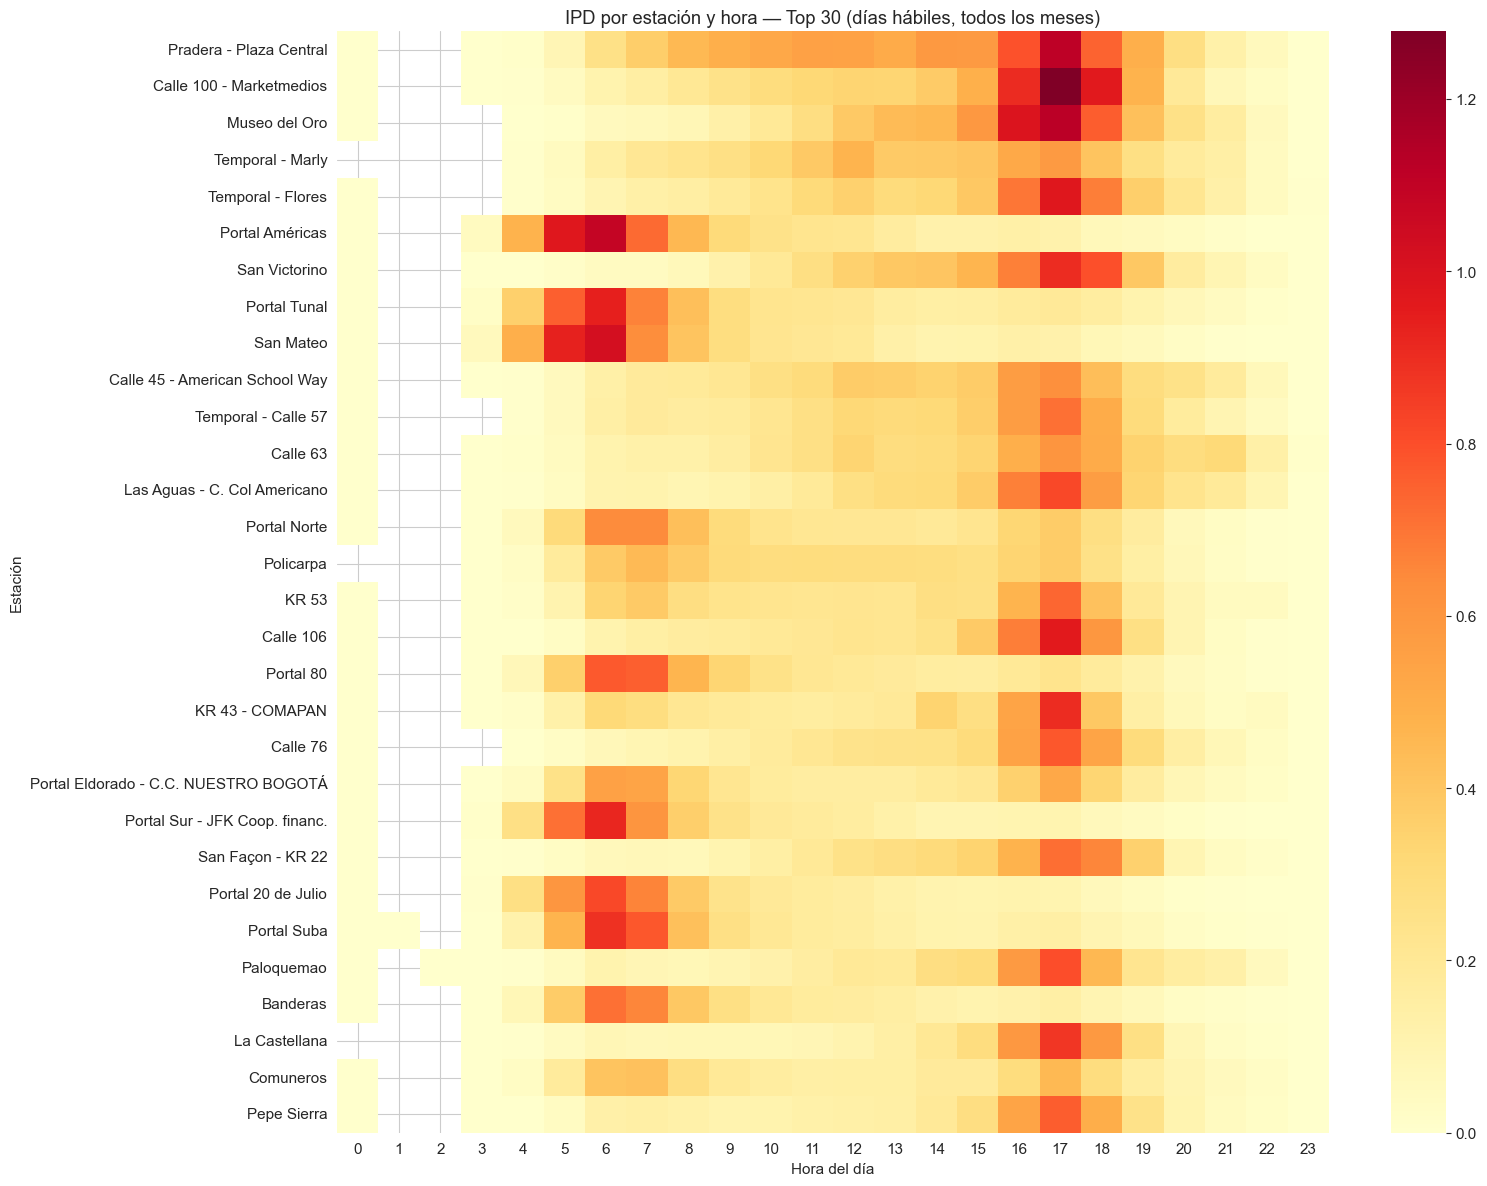

In [8]:
# =============================================
# HEATMAP: IPD POR ESTACIÓN Y HORA (DÍAS HÁBILES, TODOS LOS MESES)
# =============================================

# Todos los meses (días hábiles no festivos), coherente con la decisión metodológica (s3.6)
habil_normal = ipd_df[
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0)
]

heatmap_data = habil_normal.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='estacion', columns='hora', values='ipd')
heatmap_pivot['mean_ipd'] = heatmap_pivot.mean(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('mean_ipd', ascending=False).drop('mean_ipd', axis=1)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(heatmap_pivot.head(30), cmap='YlOrRd', annot=False,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('IPD por estación y hora — Top 30 (días hábiles, todos los meses)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Estación')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig2_heatmap_ipd.png'), dpi=150, bbox_inches='tight')
plt.show()

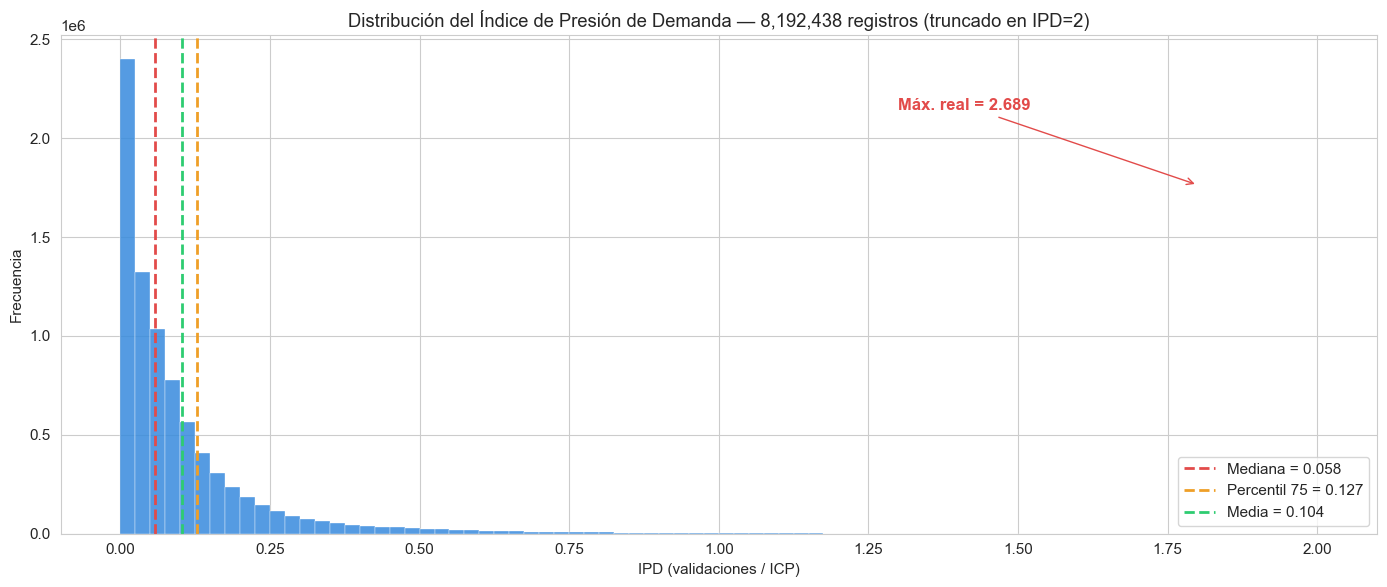

In [9]:
# =============================================
# DISTRIBUCIÓN DEL IPD (HISTOGRAMA)
# =============================================

fig, ax = plt.subplots(figsize=(14, 6))

# Histograma con corte en IPD=2 para ver bien la distribución
ipd_plot = ipd_df['ipd'].clip(upper=2.0)
ax.hist(ipd_plot, bins=80, color='#378ADD', edgecolor='white', linewidth=0.3, alpha=0.85)

# Líneas de referencia
ax.axvline(ipd_df['ipd'].median(), color='#E24B4A', linestyle='--', linewidth=2,
           label=f'Mediana = {ipd_df["ipd"].median():.3f}')
ax.axvline(ipd_df['ipd'].quantile(0.75), color='#EF9F27', linestyle='--', linewidth=2,
           label=f'Percentil 75 = {ipd_df["ipd"].quantile(0.75):.3f}')
ax.axvline(ipd_df['ipd'].mean(), color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Media = {ipd_df["ipd"].mean():.3f}')

ax.set_xlabel('IPD (validaciones / ICP)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del Índice de Presión de Demanda — {len(ipd_df):,} registros (truncado en IPD=2)')
ax.legend(fontsize=11)
ax.annotate(f'Máx. real = {ipd_df["ipd"].max():.3f}', xy=(1.8, ax.get_ylim()[1]*0.7),
            fontsize=12, color='#E24B4A', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E24B4A'),
            xytext=(1.3, ax.get_ylim()[1]*0.85))
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig0_distribucion_ipd.png'), dpi=150, bbox_inches='tight')
plt.show()

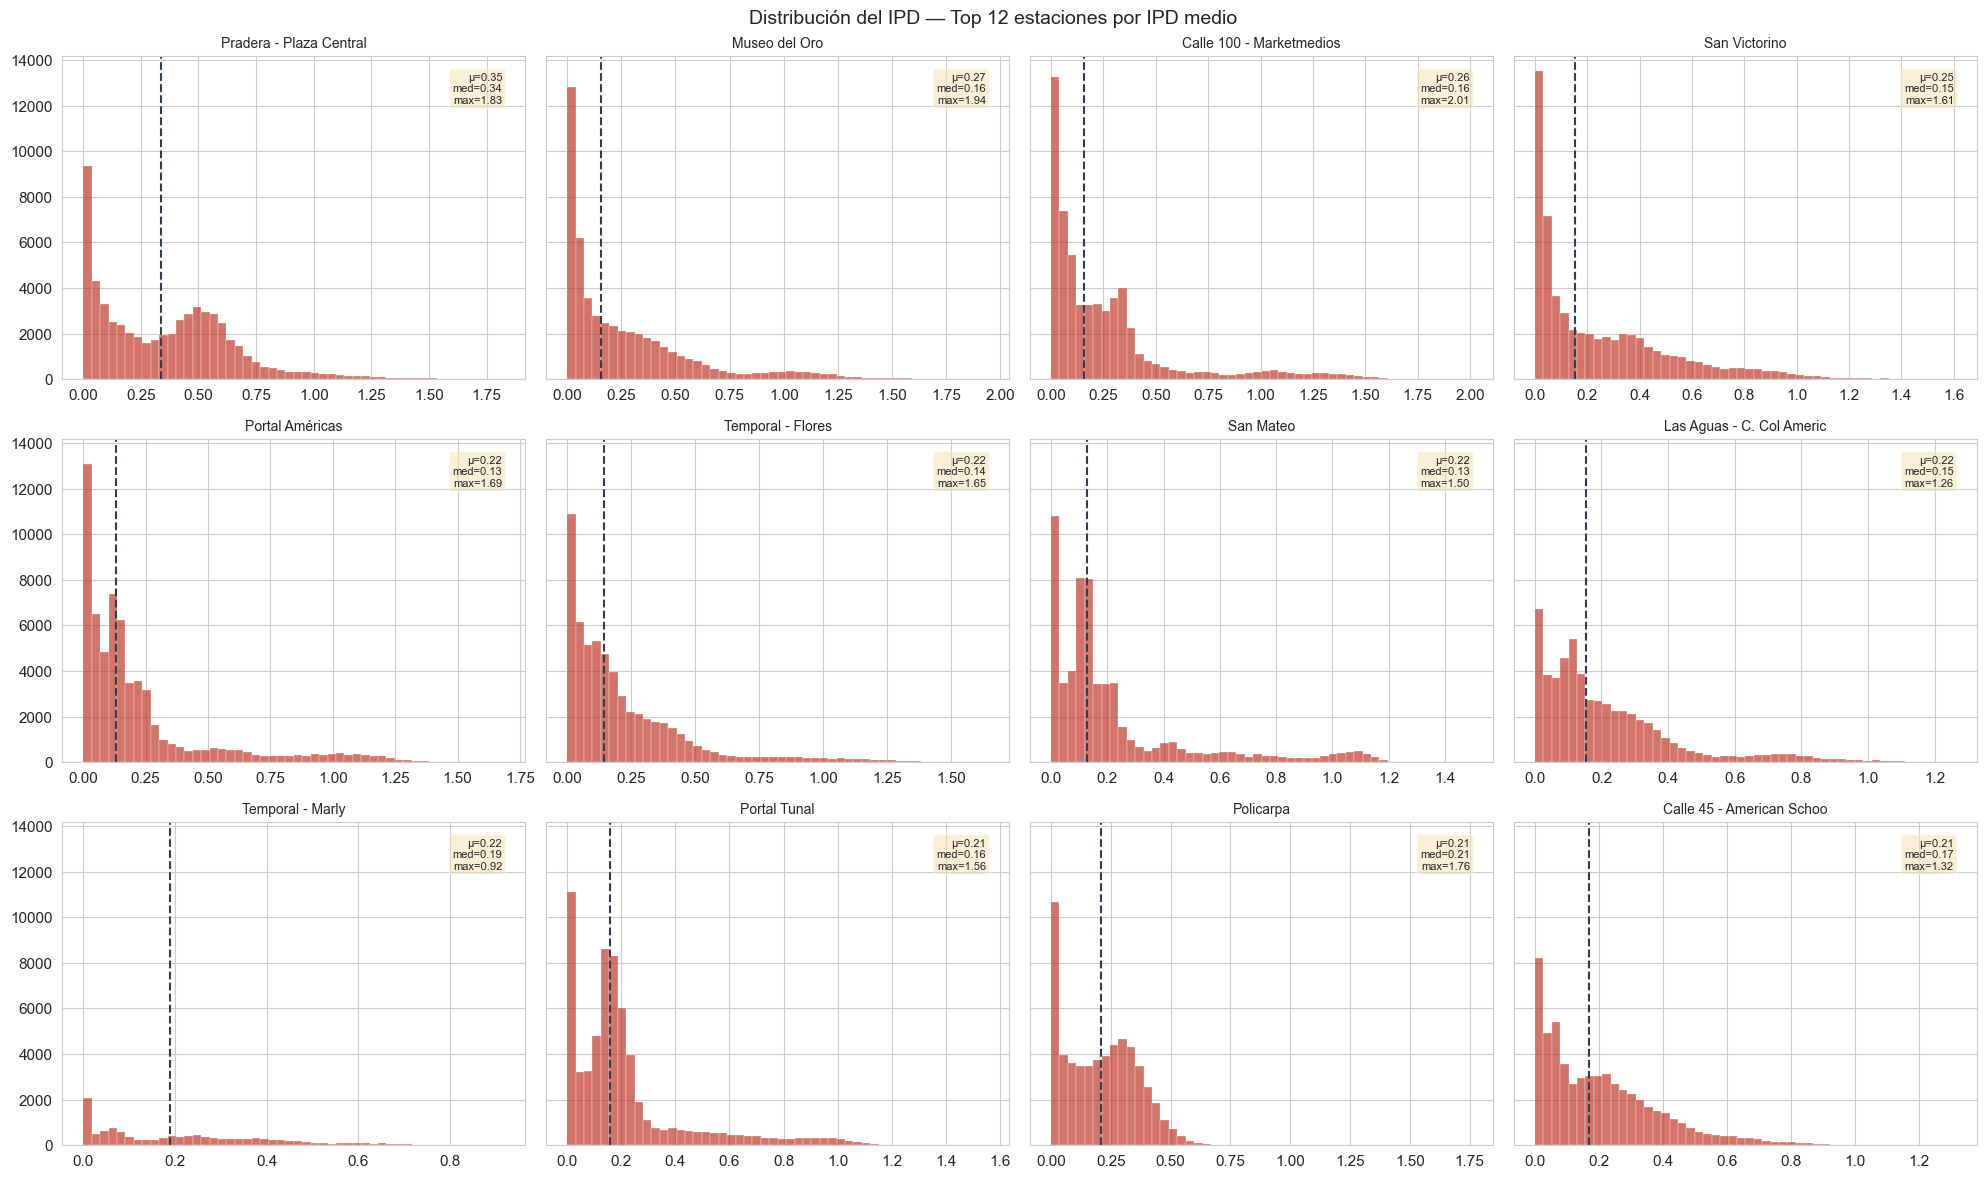

In [10]:
# =============================================
# DISTRIBUCIONES POR ESTACIÓN INDIVIDUAL
# =============================================

# Top 12 estaciones por IPD medio
top_est = ipd_df.groupby('estacion')['ipd'].mean().nlargest(12).index

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes_flat = axes.flatten()

for i, est in enumerate(top_est):
    ax = axes_flat[i]
    data = ipd_df[ipd_df['estacion'] == est]['ipd']
    ax.hist(data, bins=50, color='#c0392b', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='#2c3e50', linestyle='--', linewidth=1.5)
    ax.set_title(est[:25], fontsize=10)
    ax.set_xlabel('')
    
    # El truco es mantener el f-string en una sola línea o usar triple comilla
    stats_text = f'μ={data.mean():.2f}\nmed={data.median():.2f}\nmax={data.max():.2f}'
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribución del IPD — Top 12 estaciones por IPD medio', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_distribucion_por_estacion.png'), dpi=150, bbox_inches='tight')
plt.show()

=== TOP 20 ESTACIONES POR % DE OUTLIERS (IQR) ===
                      estacion  n_registros  pct_outliers  max_ipd  upper_fence
      Terreros - Hospital C.V.        57633     14.266132 1.632857     0.254147
                          Bosa        59281     13.835799 2.328099     0.268388
                     León XIII        57700     12.823224 0.647319     0.186987
                     San Mateo        58987     12.677370 1.496617     0.487030
                 La Castellana        56018     12.312114 1.463054     0.326355
                  Portal Tunal        63334     11.977769 1.556566     0.468182
                  Patio Bonito         9753     11.801497 0.670701     0.074916
               Portal Américas        62208     11.797518 1.687273     0.559545
                   Country Sur        59225     11.694386 1.252881     0.227555
             Biblioteca Tintal        59681     11.673732 1.106899     0.231820
Portal Sur - JFK Coop. financ.        59836     11.595026 1.339809    

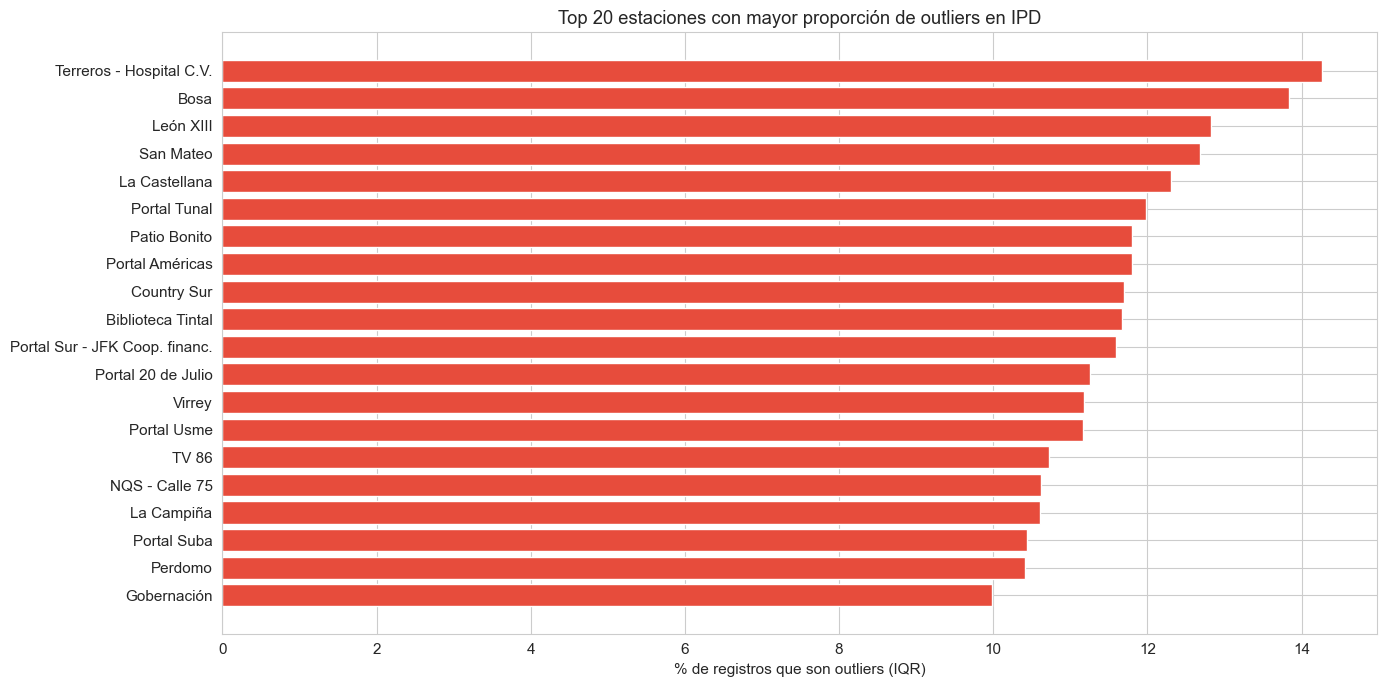

In [11]:
# =============================================
# DETECCIÓN DE OUTLIERS
# =============================================

# Outliers por estación usando IQR
outlier_summary = []
for est in ipd_df['estacion'].unique():
    data = ipd_df[ipd_df['estacion'] == est]['ipd']
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_outliers = (data > upper).sum()
    pct_outliers = n_outliers / len(data) * 100
    outlier_summary.append({
        'estacion': est, 'n_registros': len(data),
        'q1': q1, 'q3': q3, 'iqr': iqr, 'upper_fence': upper,
        'n_outliers': n_outliers, 'pct_outliers': pct_outliers,
        'max_ipd': data.max()
    })

outliers_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)

print("=== TOP 20 ESTACIONES POR % DE OUTLIERS (IQR) ===")
print(outliers_df.head(20)[['estacion', 'n_registros', 'pct_outliers', 'max_ipd', 'upper_fence']].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
top_outliers = outliers_df.head(20)
ax.barh(range(len(top_outliers)), top_outliers['pct_outliers'].values, color='#e74c3c')
ax.set_yticks(range(len(top_outliers)))
ax.set_yticklabels(top_outliers['estacion'].values)
ax.set_xlabel('% de registros que son outliers (IQR)')
ax.set_title('Top 20 estaciones con mayor proporción de outliers en IPD')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_outliers.png'), dpi=150, bbox_inches='tight')
plt.show()

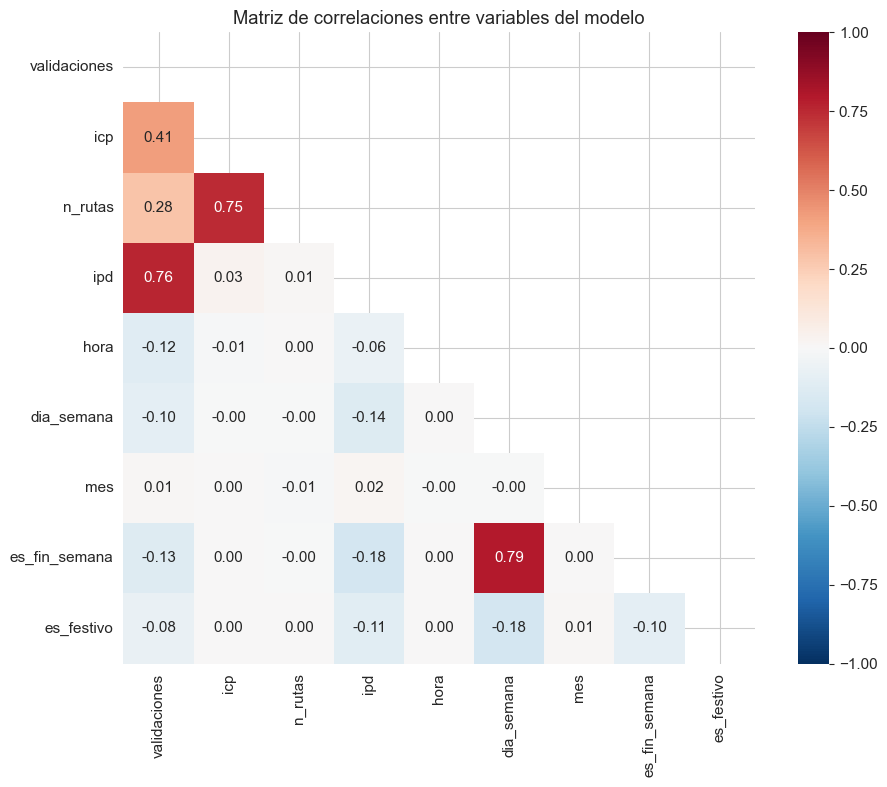

In [12]:
# =============================================
# CORRELACIONES ENTRE VARIABLES
# =============================================

corr_vars = ['validaciones', 'icp', 'n_rutas', 'ipd', 'hora', 'dia_semana',
             'mes', 'es_fin_semana', 'es_festivo']
corr_matrix = ipd_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Matriz de correlaciones entre variables del modelo')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_correlaciones.png'), dpi=150, bbox_inches='tight')
plt.show()

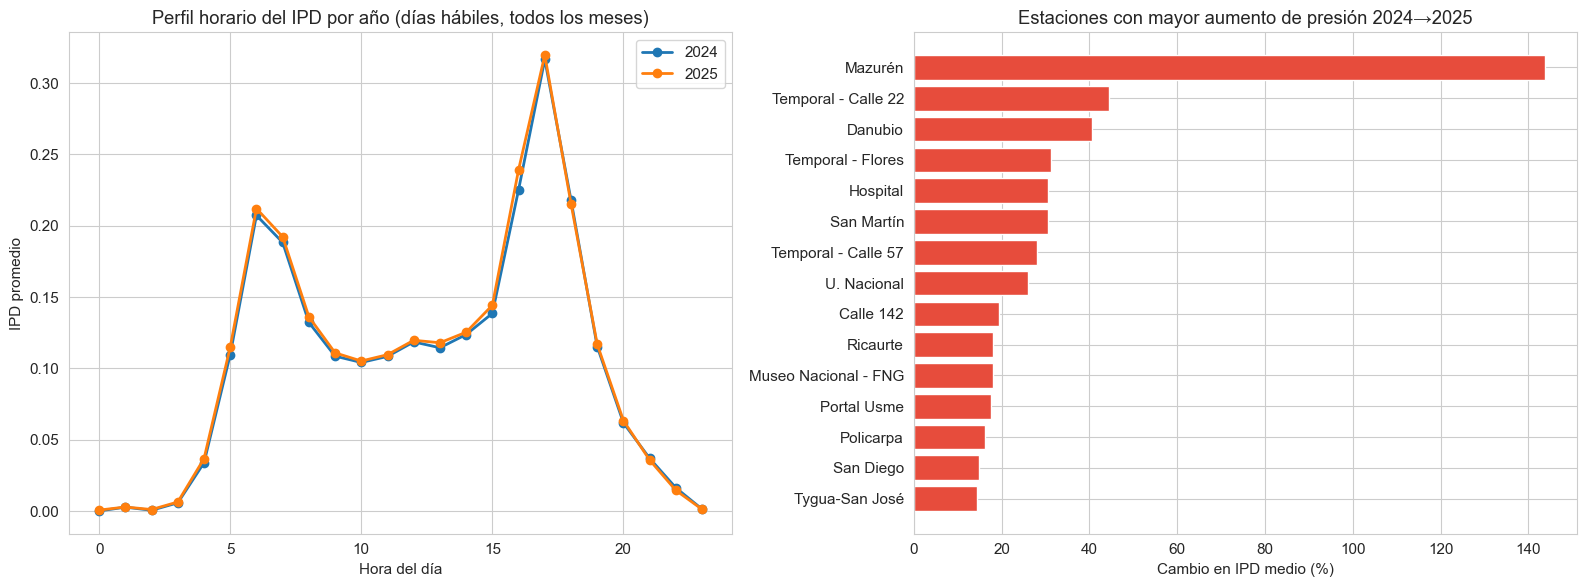


=== ESTACIONES CON CIERRES POR OBRAS DEL METRO ===
  Calle 72                        Sin datos suficientes en ambos años
  Calle 63                        Sin datos suficientes en ambos años
  Calle 26                        2024=0.110  2025=0.003  cambio=-97.2%
  AV. 39                          2024=0.097  2025=0.093  cambio=-3.5%
  Calle 19                        2024=0.069  2025=0.046  cambio=-33.6%
  Tercer Milenio                  2024=0.059  2025=0.042  cambio=-29.8%
  Hospital                        2024=0.043  2025=0.056  cambio=+30.6%
  SENA                            Sin datos suficientes en ambos años

Mann-Whitney U test (2024 vs 2025):
  U = 3,746,489,176,332, p = 1.1195e-85
  Mediana 2024 = 0.0747, Mediana 2025 = 0.0772


In [13]:
# =============================================
# COMPARACIÓN INTERANUAL 2024 vs 2025
# =============================================

ipd_df['anio'] = ipd_df['fecha'].dt.year

# Filtrar meses normales y días hábiles
# Todos los meses (días hábiles no festivos)
hab = ipd_df[
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0)
]

# IPD promedio por hora, separado por año
perfil_anual = hab.groupby(['anio', 'hora'])['ipd'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Perfil horario por año
for anio in [2024, 2025]:
    data = perfil_anual[perfil_anual['anio'] == anio]
    axes[0].plot(data['hora'], data['ipd'], marker='o', linewidth=2, label=str(anio))
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('IPD promedio')
axes[0].set_title('Perfil horario del IPD por año (días hábiles, todos los meses)')
axes[0].legend()

# Panel 2: Top estaciones — cambio 2024 vs 2025
ipd_anual = hab.groupby(['estacion', 'anio'])['ipd'].mean().reset_index()
ipd_pivot = ipd_anual.pivot(index='estacion', columns='anio', values='ipd')
ipd_pivot.columns = ['ipd_2024', 'ipd_2025']
ipd_pivot['cambio_pct'] = (ipd_pivot['ipd_2025'] / ipd_pivot['ipd_2024'] - 1) * 100
ipd_pivot = ipd_pivot.dropna()

# Top 15 con mayor aumento
top_cambio = ipd_pivot.nlargest(15, 'cambio_pct')
colors = ['#e74c3c' if c > 0 else '#27ae60' for c in top_cambio['cambio_pct']]
axes[1].barh(range(len(top_cambio)), top_cambio['cambio_pct'].values, color=colors)
axes[1].set_yticks(range(len(top_cambio)))
axes[1].set_yticklabels(top_cambio.index)
axes[1].set_xlabel('Cambio en IPD medio (%)')
axes[1].set_title('Estaciones con mayor aumento de presión 2024→2025')
axes[1].axvline(x=0, color='gray', linewidth=0.5)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_comparacion_interanual.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estaciones con cierres por Metro
est_metro = ['Calle 72', 'Calle 63', 'Calle 26', 'AV. 39', 'Calle 19',
             'Tercer Milenio', 'Hospital', 'SENA']
print("\n=== ESTACIONES CON CIERRES POR OBRAS DEL METRO ===")
for est in est_metro:
    row = ipd_pivot.loc[est] if est in ipd_pivot.index else None
    if row is not None:
        print(f"  {est:30s}  2024={row['ipd_2024']:.3f}  2025={row['ipd_2025']:.3f}  cambio={row['cambio_pct']:+.1f}%")
    else:
        print(f"  {est:30s}  Sin datos suficientes en ambos años")

# Test estadístico: ¿el IPD de 2025 es significativamente diferente al de 2024?
from scipy import stats
ipd_2024 = hab[hab['anio'] == 2024]['ipd']
ipd_2025 = hab[hab['anio'] == 2025]['ipd']
u_stat, p_value = stats.mannwhitneyu(ipd_2024, ipd_2025, alternative='two-sided')
print(f"\nMann-Whitney U test (2024 vs 2025):")
print(f"  U = {u_stat:,.0f}, p = {p_value:.4e}")
print(f"  Mediana 2024 = {ipd_2024.median():.4f}, Mediana 2025 = {ipd_2025.median():.4f}")

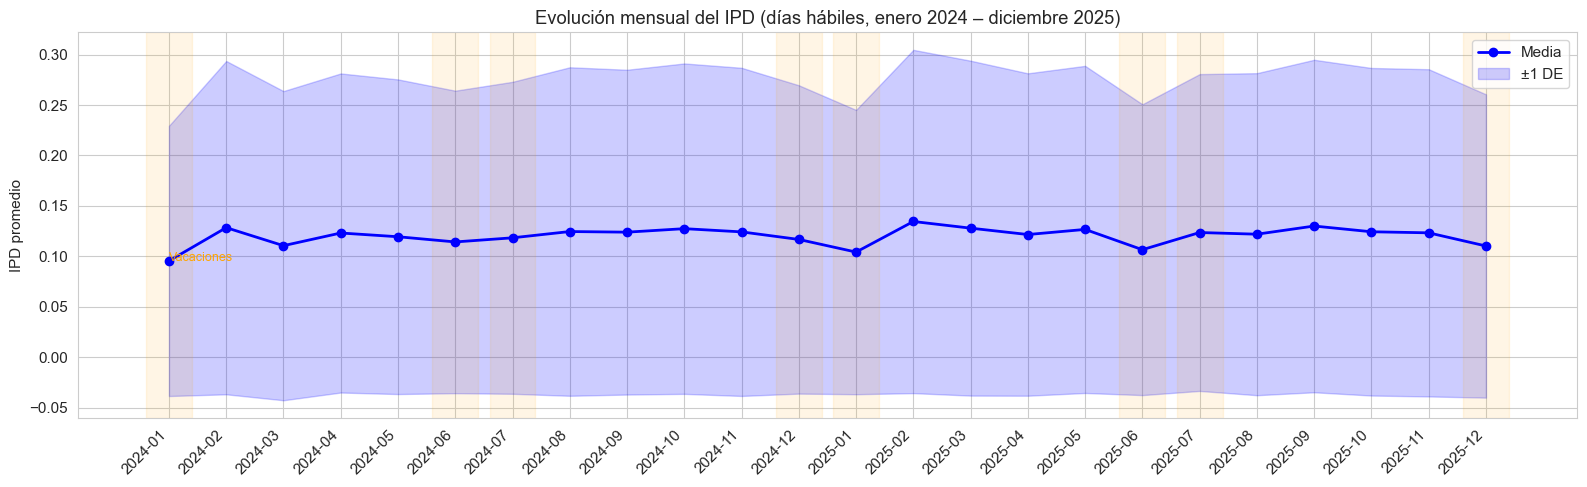

In [14]:
# =============================================
# ANÁLISIS DE ESTACIONALIDAD MENSUAL
# =============================================

hab_mensual = ipd_df[ipd_df['dia_semana'] < 5].copy()
hab_mensual['periodo'] = hab_mensual['fecha'].dt.to_period('M').astype(str)

mensual = hab_mensual.groupby('periodo')['ipd'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(len(mensual)), mensual['mean'], 'b-o', label='Media', linewidth=2)
ax.fill_between(range(len(mensual)),
                mensual['mean'] - mensual['std'],
                mensual['mean'] + mensual['std'],
                alpha=0.2, color='blue', label='±1 DE')
ax.set_xticks(range(len(mensual)))
ax.set_xticklabels(mensual['periodo'], rotation=45, ha='right')
ax.set_ylabel('IPD promedio')
ax.set_title('Evolución mensual del IPD (días hábiles, enero 2024 – diciembre 2025)')
ax.legend()

# Marcar meses de vacaciones
for i, m in enumerate(mensual['periodo']):
    if any(m.endswith(f'-{str(v).zfill(2)}') for v in [1, 6, 7, 12]):
        ax.axvspan(i-0.4, i+0.4, alpha=0.1, color='orange')

ax.annotate('Vacaciones', xy=(0, mensual['mean'].iloc[0]), fontsize=9, color='orange')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_estacionalidad.png'), dpi=150, bbox_inches='tight')
plt.show()

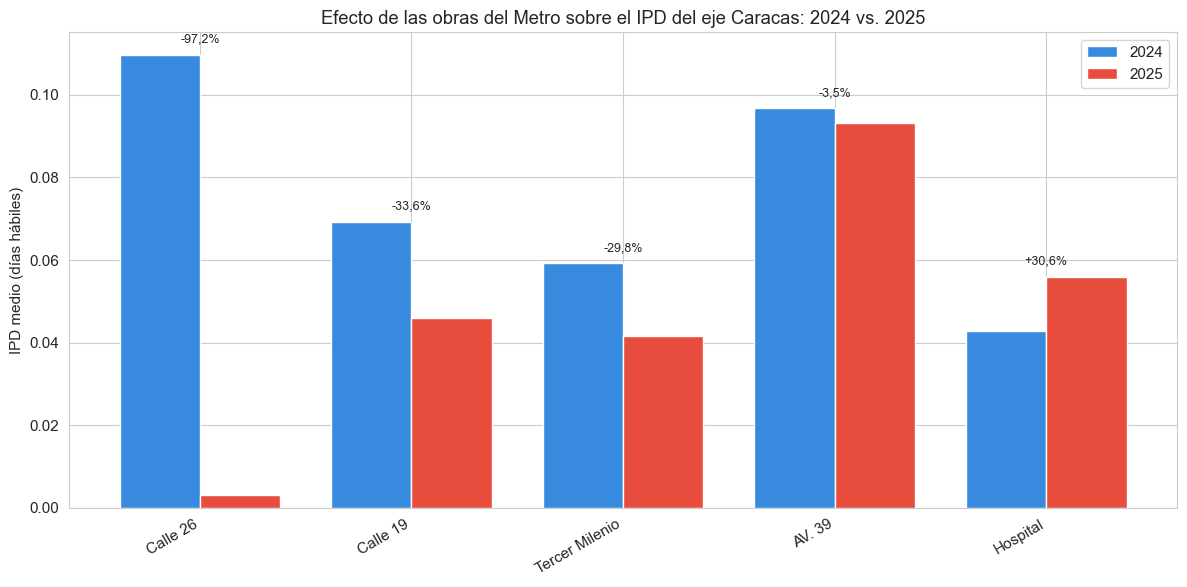

In [15]:
# =============================================
# FIGURA: EFECTO DEL METRO SOBRE EL IPD (EJE CARACAS), 2024 vs 2025
# =============================================
import numpy as np

metro_plot = ipd_pivot.loc[[e for e in est_metro if e in ipd_pivot.index]].copy()
metro_plot = metro_plot.sort_values('cambio_pct')   # de mayor caída a mayor aumento

x = np.arange(len(metro_plot)); ancho = 0.38
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - ancho/2, metro_plot['ipd_2024'], ancho, label='2024', color='#378ADD')
ax.bar(x + ancho/2, metro_plot['ipd_2025'], ancho, label='2025', color='#e74c3c')
for xi, (_, row) in zip(x, metro_plot.iterrows()):
    ax.text(xi, max(row['ipd_2024'], row['ipd_2025']) + 0.003,
            f"{row['cambio_pct']:+.1f}%".replace('.', ','), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metro_plot.index, rotation=30, ha='right')
ax.set_ylabel('IPD medio (días hábiles)')
ax.set_title('Efecto de las obras del Metro sobre el IPD del eje Caracas: 2024 vs. 2025')
ax.legend()
plt.tight_layout()
# Nombre propio: antes colisionaba con la figura de cambios extremos por estación
# (más abajo), que la sobrescribía al guardarse con el mismo nombre de archivo.
plt.savefig(os.path.join(OUT_FIG, 'fig_eda_impacto_metro_caracas.png'), dpi=150, bbox_inches='tight')
plt.show()

### Impacto del Metro (cambio interanual por estación)

Se evalúa el efecto de los cierres por obras del Metro —contexto central del planteamiento del problema— comparando demanda e IPD por estación entre 2024 y 2025.

Estaciones con MAYOR CAIDA de demanda 2024 -> 2025 (posible cierre/afectacion):
                         val_2024  val_2025  ipd_2024  ipd_2025  cambio_val_pct  cambio_ipd_pct
estacion                                                                                       
Calle 146                  169.33      4.58      0.09      0.00          -97.30          -97.30
Calle 26                   112.22      3.16      0.11      0.00          -97.19          -97.19
Patio Bonito                83.30     14.98      0.05      0.01          -82.01          -82.01
Consuelo                    48.94     22.46      0.05      0.02          -54.10          -54.10
Calle 19                   118.80     78.86      0.07      0.05          -33.61          -33.61
Tercer Milenio              59.93     42.09      0.06      0.04          -29.76          -29.76
Pradera - Plaza Central    158.31    136.56      0.45      0.39          -13.74          -13.74
Quiroga                     45.06     40.17      0.04   

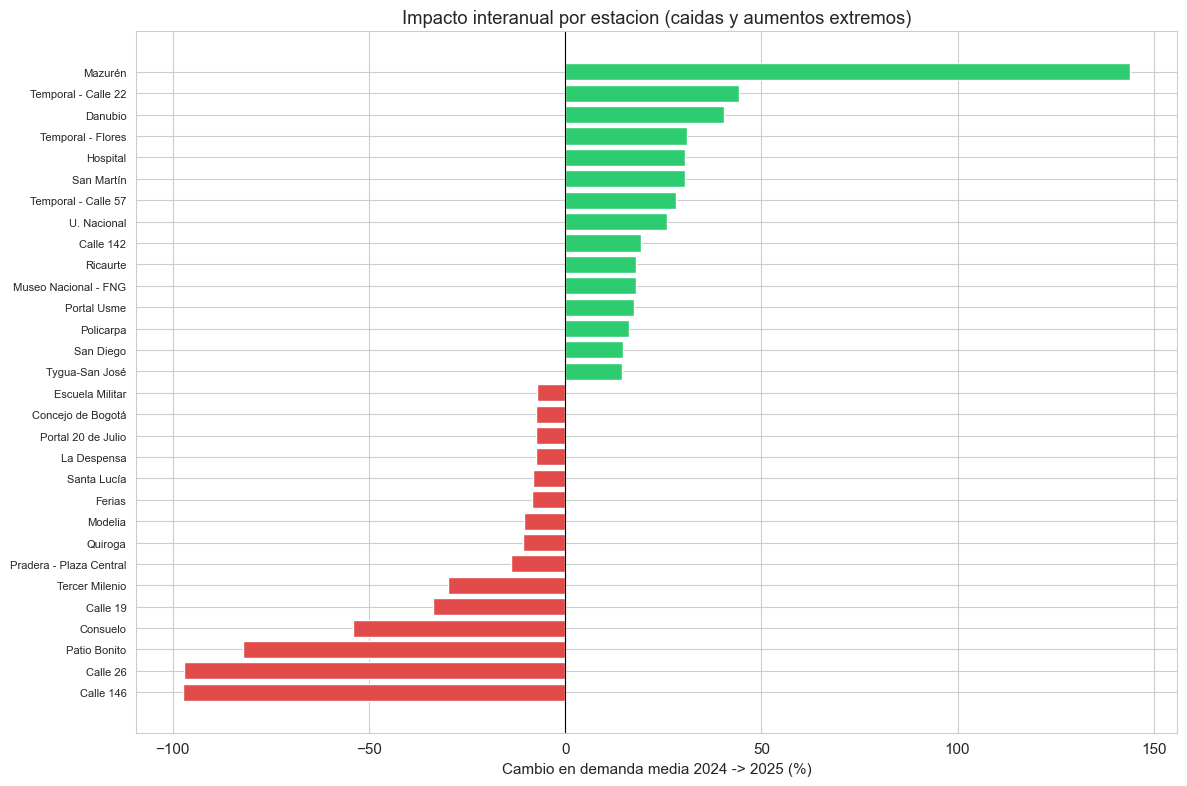

In [16]:
# =============================================
# IMPACTO DEL METRO: CAMBIO POR ESTACION 2024 vs 2025
# =============================================
# Cuantifica el cambio interanual de demanda e IPD por estacion para
# identificar las estaciones mas afectadas por las obras del Metro
# (caidas por cierre y aumentos por redistribucion de demanda).

ipd_df['anio'] = ipd_df['fecha'].dt.year
# Todos los meses (días hábiles no festivos)
comp = ipd_df[
    (ipd_df['dia_semana'] < 5) &
    (ipd_df['es_festivo'] == 0)
]

piv = comp.groupby(['estacion', 'anio']).agg(
    validaciones=('validaciones', 'mean'),
    ipd=('ipd', 'mean')
).reset_index()

dem  = piv.pivot(index='estacion', columns='anio', values='validaciones')
ipdc = piv.pivot(index='estacion', columns='anio', values='ipd')

comunes = dem.dropna().index
cambio = pd.DataFrame({
    'val_2024': dem.loc[comunes, 2024], 'val_2025': dem.loc[comunes, 2025],
    'ipd_2024': ipdc.loc[comunes, 2024], 'ipd_2025': ipdc.loc[comunes, 2025],
})
cambio['cambio_val_pct'] = (cambio['val_2025'] / cambio['val_2024'] - 1) * 100
cambio['cambio_ipd_pct'] = (cambio['ipd_2025'] / cambio['ipd_2024'] - 1) * 100
cambio = cambio.sort_values('cambio_val_pct')

print("Estaciones con MAYOR CAIDA de demanda 2024 -> 2025 (posible cierre/afectacion):")
print(cambio.head(10).round(2).to_string())
print("\nEstaciones con MAYOR AUMENTO de demanda 2024 -> 2025 (posible redistribucion):")
print(cambio.tail(10).round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
extremos = pd.concat([cambio.head(15), cambio.tail(15)])
colores = ['#E24B4A' if x < 0 else '#2ecc71' for x in extremos['cambio_val_pct']]
ax.barh(range(len(extremos)), extremos['cambio_val_pct'], color=colores)
ax.set_yticks(range(len(extremos)))
ax.set_yticklabels([e[:28] for e in extremos.index], fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cambio en demanda media 2024 -> 2025 (%)')
ax.set_title('Impacto interanual por estacion (caidas y aumentos extremos)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_eda_impacto_metro.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Análisis de sensibilidad del piso de la función V — §3.4

El piso 0,30 es la decisión paramétrica más discutible del ICP, así que se somete a prueba: se recalculan el ICP, el IPD y la tipología de conglomerados para pisos alternativos **0,10, 0,20, 0,40 y 0,50** (valores alrededor del elegido) y para la **ponderación plana** (factor 1 en todas las posiciones, es decir, capacidad nominal sin función V: el contrafactual de no usar la V).

Dos métricas de robustez (§3.4):
- **Correlación del ICP entre pisos:** si es muy alta, el ordenamiento de cobertura entre estaciones no depende del piso elegido.
- **Índice de Rand ajustado (ARI)** entre la tipología de conglomerados de cada piso y la del piso elegido (V≥0,30). El ARI mide la concordancia entre dos particiones corrigiendo por azar (1 = idénticas; 0 = coincidencia esperable por azar). Aquí se usa K=4 replicando la configuración del OE4; la selección de K se justifica y valida en el cuaderno 03.

=== CORRELACIÓN DE ICP ENTRE DISTINTOS PISOS ===
               V≥0.10  V≥0.20  V≥0.30  V≥0.40  V≥0.50  Plano (sin V)
V≥0.10         1.0000  0.9993  0.9950  0.9829  0.9592         0.7128
V≥0.20         0.9993  1.0000  0.9978  0.9881  0.9668         0.7275
V≥0.30         0.9950  0.9978  1.0000  0.9958  0.9804         0.7585
V≥0.40         0.9829  0.9881  0.9958  1.0000  0.9939         0.8038
V≥0.50         0.9592  0.9668  0.9804  0.9939  1.0000         0.8555
Plano (sin V)  0.7128  0.7275  0.7585  0.8038  0.8555         1.0000


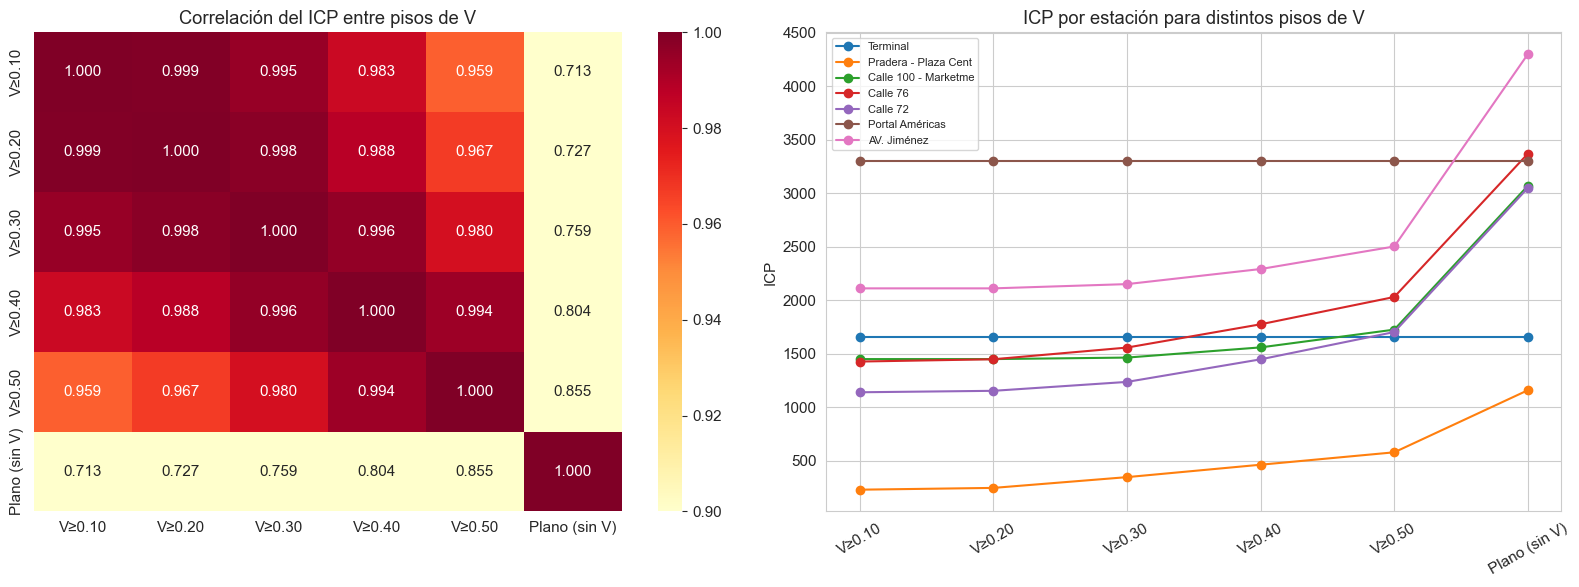

In [17]:
# =============================================
# SENSIBILIDAD DEL PISO V: IMPACTO EN ICP
# =============================================

pisos = [0.10, 0.20, 0.30, 0.40, 0.50, 1.00]  # = sin ponderación (plano)
piso_labels = ['V≥0.10', 'V≥0.20', 'V≥0.30', 'V≥0.40', 'V≥0.50', 'Plano (sin V)']

# Recalcular ICP para cada piso
resultados_piso = {}
for piso, label in zip(pisos, piso_labels):
    if piso >= 1.0:
        fv = pd.Series(1.0, index=matriz.index)
    else:
        fv = matriz['factor_v_raw'].clip(lower=piso) if 'factor_v_raw' in matriz.columns else (1 - 2 * matriz['dist_extremo'] / matriz['len_ruta']).clip(lower=piso)
    
    m_temp = matriz.copy()
    m_temp['cap_v_temp'] = m_temp['capacidad'] * fv
    icp_temp = m_temp.groupby('estacion')['cap_v_temp'].sum()
    resultados_piso[label] = icp_temp

# Correlación entre pisos
print("=== CORRELACIÓN DE ICP ENTRE DISTINTOS PISOS ===")
icp_all_pisos = pd.DataFrame(resultados_piso)
print(icp_all_pisos.corr().round(4).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Correlación
sns.heatmap(icp_all_pisos.corr(), annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], vmin=0.9, vmax=1.0)
axes[0].set_title('Correlación del ICP entre pisos de V')

# Panel 2: ICP de estaciones clave para cada piso
est_clave = ['Terminal', 'Pradera - Plaza Central', 'Calle 100 - Marketmedios',
             'Calle 76', 'Calle 72', 'Portal Américas', 'AV. Jiménez']
est_clave = [e for e in est_clave if e in icp_all_pisos.index]

for est in est_clave:
    values = [icp_all_pisos.loc[est, l] for l in piso_labels]
    axes[1].plot(range(len(pisos)), values, marker='o', label=est[:20])

axes[1].set_xticks(range(len(pisos)))
axes[1].set_xticklabels(piso_labels, rotation=30)
axes[1].set_ylabel('ICP')
axes[1].set_title('ICP por estación para distintos pisos de V')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_sensibilidad_icp_pisos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# =============================================
# SENSIBILIDAD: IMPACTO EN IPD Y CLUSTERS
# =============================================

from sklearn.metrics import adjusted_rand_score

# Para cada piso, recalcular IPD y clusters. K=4 fijo: replica la configuración del
# OE4 para medir la estabilidad de la tipología (la selección de K se valida en 03).
cluster_results = {}
ipd_stats_by_piso = {}

for piso, label in zip(pisos, piso_labels):
    # Recalcular ICP
    if piso >= 1.0:
        fv = pd.Series(1.0, index=matriz.index)
    else:
        fv = (1 - 2 * matriz['dist_extremo'] / matriz['len_ruta']).clip(lower=piso)
    
    m_temp = matriz.copy()
    m_temp['cap_v_temp'] = m_temp['capacidad'] * fv
    icp_temp = m_temp.groupby('estacion').agg(
        icp_temp=('cap_v_temp', 'sum'),
        n_rutas_temp=('ruta', 'nunique')
    ).reset_index()
    
    # Recalcular IPD
    ipd_temp = validaciones.merge(icp_temp[['estacion', 'icp_temp', 'n_rutas_temp']], on='estacion', how='left')
    ipd_temp = ipd_temp[ipd_temp['icp_temp'].notna() & (ipd_temp['icp_temp'] > 0)].copy()
    ipd_temp['ipd_temp'] = ipd_temp['validaciones'] / ipd_temp['icp_temp']
    
    # Estadísticas del IPD
    ipd_stats_by_piso[label] = {
        'mean': ipd_temp['ipd_temp'].mean(),
        'median': ipd_temp['ipd_temp'].median(),
        'max': ipd_temp['ipd_temp'].max(),
        'p75': ipd_temp['ipd_temp'].quantile(0.75),
    }
    
    # Clustering
    hab_temp = ipd_temp[
        (ipd_temp['dia_semana'] < 5) &
        (ipd_temp['es_festivo'] == 0)
    ]
    perf_temp = hab_temp.groupby(['estacion', 'hora'])['ipd_temp'].mean().reset_index()
    piv_temp = perf_temp.pivot(index='estacion', columns='hora', values='ipd_temp').fillna(0)
    piv_temp['ipd_mean'] = piv_temp.mean(axis=1)
    piv_temp['ipd_std'] = piv_temp.iloc[:, :-1].std(axis=1)
    piv_temp['ipd_max'] = piv_temp.iloc[:, :-2].max(axis=1)
    piv_temp.columns = piv_temp.columns.astype(str)
    
    X_temp = StandardScaler().fit_transform(piv_temp)
    km_temp = KMeans(n_clusters=4, random_state=42, n_init=10)
    piv_temp['cluster'] = km_temp.fit_predict(X_temp)
    sil_temp = silhouette_score(X_temp, piv_temp['cluster'])
    
    cluster_results[label] = {
        'clusters': piv_temp['cluster'].to_dict(),
        'silhouette': sil_temp,
        'sizes': piv_temp['cluster'].value_counts().sort_index().to_dict(),
    }
    print(f"{label}: silueta={sil_temp:.3f}, tamaños={dict(sorted(piv_temp['cluster'].value_counts().items()))}")

# Adjusted Rand Index entre cada par de pisos
print("\n=== ADJUSTED RAND INDEX (ESTABILIDAD DE CLUSTERS) ===")
ref_label = 'V≥0.30'  # nuestro piso elegido
ref_clusters = cluster_results[ref_label]['clusters']
for label in piso_labels:
    other = cluster_results[label]['clusters']
    common = set(ref_clusters.keys()) & set(other.keys())
    ref_arr = [ref_clusters[e] for e in common]
    other_arr = [other[e] for e in common]
    ari = adjusted_rand_score(ref_arr, other_arr)
    print(f"  {ref_label} vs {label}: ARI = {ari:.3f}")

# Tabla resumen IPD
print("\n=== ESTADÍSTICAS DEL IPD POR PISO ===")
stats_df = pd.DataFrame(ipd_stats_by_piso).T
print(stats_df.round(4).to_string())

V≥0.10: silueta=0.518, tamaños={0: 30, 1: 102, 2: 14, 3: 2}
V≥0.20: silueta=0.518, tamaños={0: 101, 1: 29, 2: 2, 3: 16}
V≥0.30: silueta=0.508, tamaños={0: 14, 1: 33, 2: 99, 3: 2}
V≥0.40: silueta=0.492, tamaños={0: 99, 1: 36, 2: 2, 3: 11}
V≥0.50: silueta=0.491, tamaños={0: 11, 1: 31, 2: 104, 3: 2}
Plano (sin V): silueta=0.605, tamaños={0: 123, 1: 14, 2: 2, 3: 9}

=== ADJUSTED RAND INDEX (ESTABILIDAD DE CLUSTERS) ===
  V≥0.30 vs V≥0.10: ARI = 0.929
  V≥0.30 vs V≥0.20: ARI = 0.936
  V≥0.30 vs V≥0.30: ARI = 1.000
  V≥0.30 vs V≥0.40: ARI = 0.904
  V≥0.30 vs V≥0.50: ARI = 0.834
  V≥0.30 vs Plano (sin V): ARI = 0.455

=== ESTADÍSTICAS DEL IPD POR PISO ===
                 mean  median     max     p75
V≥0.10         0.1142  0.0623  4.3015  0.1382
V≥0.20         0.1108  0.0610  3.0246  0.1346
V≥0.30         0.1037  0.0583  2.6888  0.1273
V≥0.40         0.0965  0.0549  2.4380  0.1194
V≥0.50         0.0895  0.0510  2.1629  0.1106
Plano (sin V)  0.0608  0.0321  1.6873  0.0705


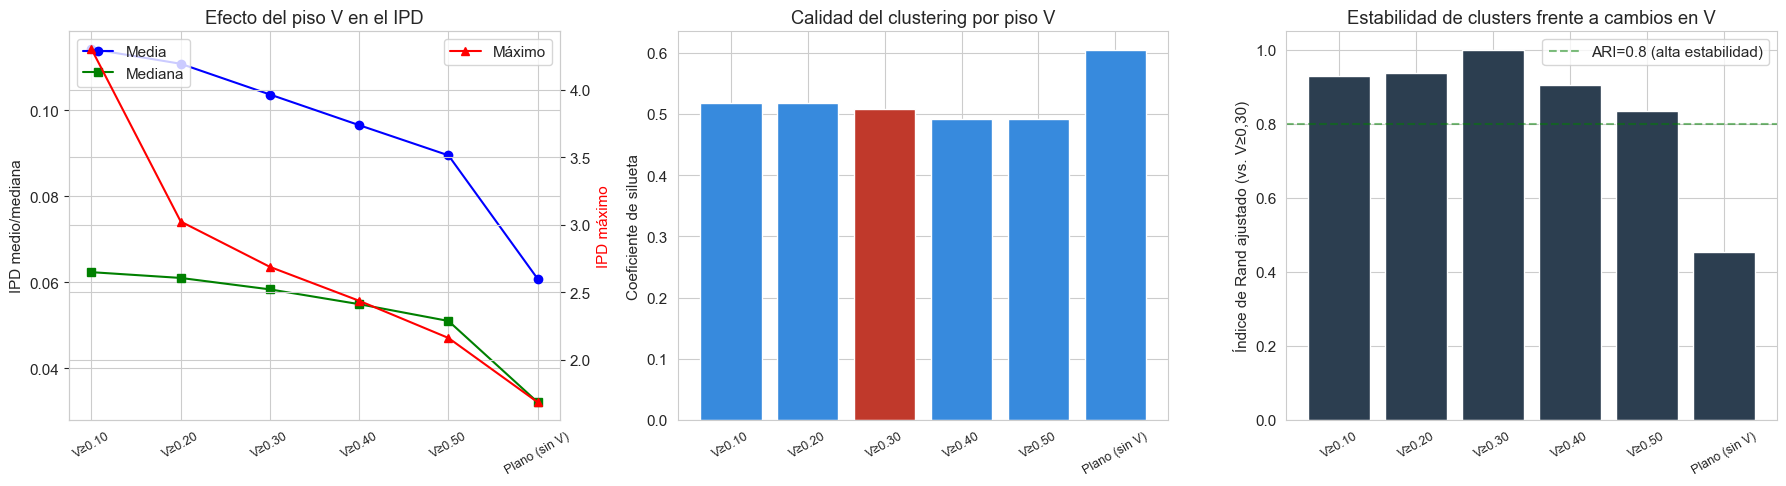


CONCLUSIÓN: Si ARI > 0.8 entre pisos adyacentes, los resultados son robustos.


In [19]:
# =============================================
# VISUALIZACIÓN: SENSIBILIDAD CONSOLIDADA
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: IPD medio y máximo por piso
stats_df_plot = pd.DataFrame(ipd_stats_by_piso).T
axes[0].plot(range(len(pisos)), stats_df_plot['mean'], 'bo-', label='Media')
axes[0].plot(range(len(pisos)), stats_df_plot['median'], 'gs-', label='Mediana')
ax0_twin = axes[0].twinx()
ax0_twin.plot(range(len(pisos)), stats_df_plot['max'], 'r^-', label='Máximo')
ax0_twin.set_ylabel('IPD máximo', color='red')
axes[0].set_xticks(range(len(pisos)))
axes[0].set_xticklabels(piso_labels, rotation=30, fontsize=9)
axes[0].set_ylabel('IPD medio/mediana')
axes[0].set_title('Efecto del piso V en el IPD')
axes[0].legend(loc='upper left')
ax0_twin.legend(loc='upper right')

# Panel 2: Silueta por piso
sils = [cluster_results[l]['silhouette'] for l in piso_labels]
axes[1].bar(range(len(pisos)), sils, color=['#378ADD' if l != 'V≥0.30' else '#c0392b' for l in piso_labels])
axes[1].set_xticks(range(len(pisos)))
axes[1].set_xticklabels(piso_labels, rotation=30, fontsize=9)
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Calidad del clustering por piso V')

# Panel 3: ARI vs V≥0.30
ari_values = []
ref_clusters_v = cluster_results[ref_label]['clusters']
for label in piso_labels:
    other = cluster_results[label]['clusters']
    common = set(ref_clusters_v.keys()) & set(other.keys())
    ref_arr = [ref_clusters_v[e] for e in common]
    other_arr = [other[e] for e in common]
    ari_values.append(adjusted_rand_score(ref_arr, other_arr))

axes[2].bar(range(len(pisos)), ari_values, color='#2c3e50')
axes[2].set_xticks(range(len(pisos)))
axes[2].set_xticklabels(piso_labels, rotation=30, fontsize=9)
axes[2].set_ylabel('Índice de Rand ajustado (vs. V≥0,30)')
axes[2].set_title('Estabilidad de clusters frente a cambios en V')
axes[2].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='ARI=0.8 (alta estabilidad)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_sensibilidad_consolidada.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nCONCLUSIÓN: Si ARI > 0.8 entre pisos adyacentes, los resultados son robustos.")

In [20]:
# === GUARDA EL PANEL CON ICP/IPD (costura hacia OE4) ===
import os; os.makedirs(DATA_INT, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)
ipd_df.to_parquet(os.path.join(DATA_INT, 'panel_icp_ipd.parquet'), index=False)
icp.to_parquet(os.path.join(DATA_INT, 'icp.parquet'), index=False)
icp.to_csv(os.path.join(OUT_TAB, 'icp_por_estacion.csv'), index=False)
print(f'Guardado panel_icp_ipd ({len(ipd_df):,} filas) e icp ({len(icp)} estaciones)')


Guardado panel_icp_ipd (8,192,438 filas) e icp (148 estaciones)
